### **Byoma A/B Test**
This notebook analyses a 6-week A/B test run by BYOMA, a Gen-Z DTC skincare brand, testing the impact of lowering the free shipping threshold from £30 to £25. 11,876 buyers were randomly assigned to the old £30 threshold (75% control) or to the new £25 threshold (25% treatment). The results are shown below:

### 1. Setup

In [15]:
import pandas as pd
import numpy as np

# Load
df = pd.read_csv("byoma_ab_test_v2.csv")
df["time_of_first_visit"] = pd.to_datetime(df["time_of_first_visit"])

# Shape, dtypes, nulls
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.head())

# Cart band
BAND_BINS   = [0, 14.99, 19.99, 24.99, 29.99, 34.99, 39.99, 999]
BAND_LABELS = ["£0–£14","£15–£19","£20–£24","£25–£29","£30–£34","£35–£39","£40+"]
df["cart_band"] = pd.cut(df["cart_value_pre_shipping"], bins=BAND_BINS, labels=BAND_LABELS)

# Treatment split
counts = df["treatment"].value_counts().sort_index()
for t, n in counts.items():
    print(f"{'Control' if t==0 else 'Treatment'}: {n:,} ({n/len(df)*100:.1f}%)")

# Summary stats by treatment
for t, label in [(0, "Control"), (1, "Treatment")]:
    sub = df[df["treatment"] == t][numeric]
    stats = sub.agg(["mean","std","min","max"]).T.round(2)
    stats.index = ["Order Value","Items/Order",
                   "Shipping Fee Charged","Shipping Cost","Profit/Customer"]
    print(f"\n{label} (n={len(sub):,})")
    print(stats.to_string())

(11876, 15)
user_id                              int64
treatment                            int64
channel                             object
device                              object
age_range                           object
new_returning                       object
cart_value_pre_shipping            float64
basket_band                          int64
converted                            int64
order_value                        float64
items_per_order                      int64
shipping_fee_charged               float64
shipping_cost_to_company           float64
profit_per_customer                float64
time_of_first_visit         datetime64[ns]
dtype: object
user_id                     0
treatment                   0
channel                     0
device                      0
age_range                   0
new_returning               0
cart_value_pre_shipping     0
basket_band                 0
converted                   0
order_value                 0
items_per_order             0

### 2. Randomization Check

                    covariate  p_value
         C(channel)[T.Google]   0.2753
      C(channel)[T.Instagram]   0.6527
          C(channel)[T.Other]   0.3772
         C(channel)[T.TikTok]   0.7508
          C(device)[T.mobile]   0.0801
        C(age_range)[T.25-34]   0.7421
        C(age_range)[T.35-44]   0.7540
          C(age_range)[T.45+]   0.2225
C(new_returning)[T.returning]   0.4496


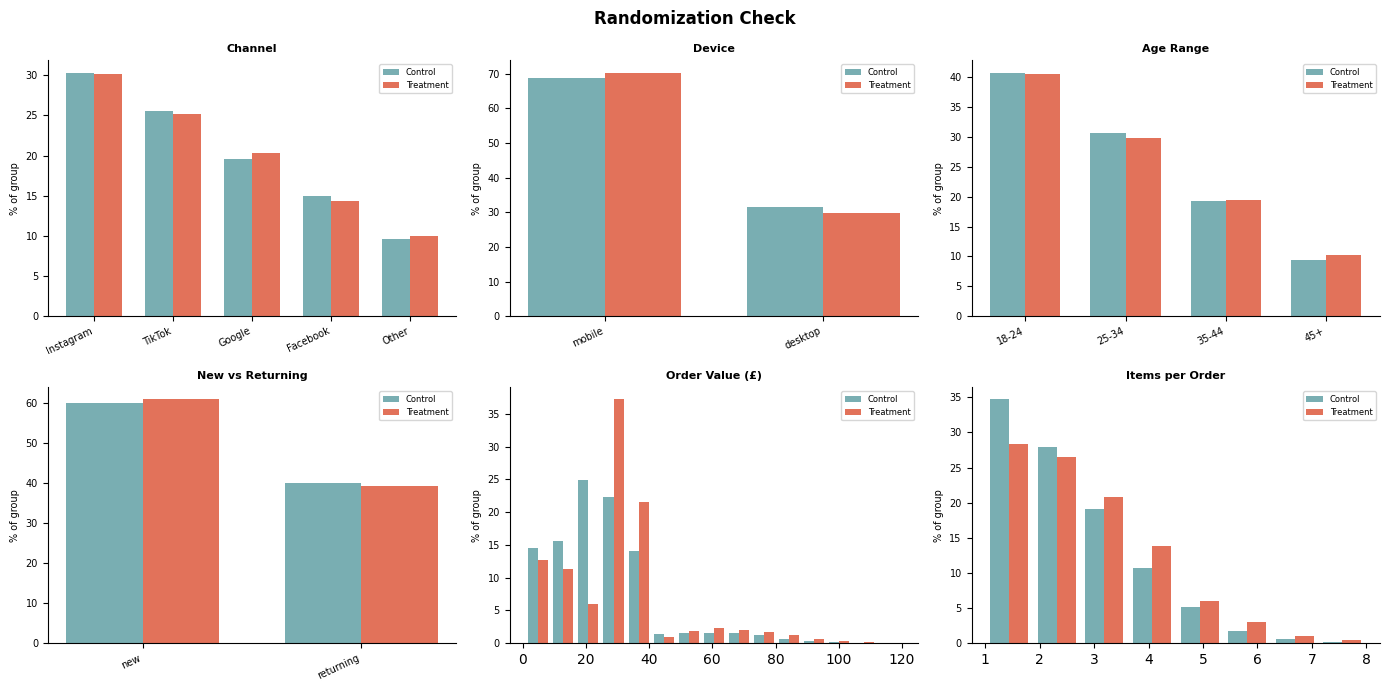

In [38]:
%matplotlib inline
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

numeric = ["order_value","items_per_order","shipping_fee_charged",
           "shipping_cost_to_company","profit_per_customer"]

CTRL, TRT = "#79AEB2", "#E2725A"
ctrl = df[df["treatment"] == 0]
trt  = df[df["treatment"] == 1]

# Logistic regression balance test
model = smf.logit(
    "treatment ~ C(channel) + C(device) + C(age_range) + C(new_returning)",
    data=df
).fit(disp=False)
pvals = model.pvalues.drop("Intercept").reset_index()
pvals.columns = ["covariate", "p_value"]
print(pvals.round(4).to_string(index=False))

def dist_chart(ax, col, title, bins=None, categorical=False):
    if categorical:
        cats = df[col].value_counts().index
        ctrl_pct = ctrl[col].value_counts(normalize=True).reindex(cats, fill_value=0) * 100
        trt_pct  = trt[col].value_counts(normalize=True).reindex(cats, fill_value=0) * 100
        x = np.arange(len(cats))
        w = 0.35
        ax.bar(x - w/2, ctrl_pct.values, width=w, color=CTRL, label="Control")
        ax.bar(x + w/2, trt_pct.values,  width=w, color=TRT,  label="Treatment")
        ax.set_xticks(x)
        ax.set_xticklabels(cats, rotation=25, ha="right", fontsize=7)
    else:
        edges = np.histogram_bin_edges(df[col].dropna(), bins=bins)
        ctrl_h, _ = np.histogram(ctrl[col].dropna(), bins=edges)
        trt_h,  _ = np.histogram(trt[col].dropna(),  bins=edges)
        ctrl_pct = ctrl_h / ctrl_h.sum() * 100
        trt_pct  = trt_h  / trt_h.sum()  * 100
        centers  = (edges[:-1] + edges[1:]) / 2
        w = (edges[1] - edges[0]) * 0.4
        ax.bar(centers - w/2, ctrl_pct, width=w, color=CTRL, label="Control")
        ax.bar(centers + w/2, trt_pct,  width=w, color=TRT,  label="Treatment")
    ax.set_title(title, fontsize=8, fontweight="bold")
    ax.set_ylabel("% of group", fontsize=7)
    ax.tick_params(axis="y", labelsize=7)
    ax.legend(fontsize=6)

variables = [
    ("channel",         "Channel",          None, True),
    ("device",          "Device",           None, True),
    ("age_range",       "Age Range",        None, True),
    ("new_returning",   "New vs Returning", None, True),
    ("order_value",     "Order Value (£)",  15,   False),
    ("items_per_order", "Items per Order",  8,    False),
]

n    = len(variables)
rows = int(np.ceil(n / 3))
fig, axes = plt.subplots(rows, 3, figsize=(14, rows * 3.5))
fig.suptitle("Randomization Check",
             fontsize=12, fontweight="bold")

for ax, (col, title, bins, cat) in zip(axes.flatten(), variables):
    dist_chart(ax, col, title, bins=bins, categorical=cat)

for ax in axes.flatten()[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

The experiment is well randomised. Looking at the charts, the blue and orange bars are nearly identical across every categorical variable. The logistic regression formalises this, since no covariate significantly predicts treatment assignment, with all p-values above 0.05. The one mild flag is device (mobile, p=0.08), which is close to the threshold but can be considered noise given the sample size. We control for it in subsequent analysis. 
The order value distribution is the one chart where the groups visibly differ. Treatment is shifted right with a spike around £25–£29, which is expected as it reflects the basket-bumping behaviour triggered by the new threshold, not a randomization failure.

### 3. Core treatment effect

In [28]:
from scipy import stats
from statsmodels.formula.api import ols

# T-test
ctrl_profit = df[df["treatment"] == 0]["profit_per_customer"]
trt_profit  = df[df["treatment"] == 1]["profit_per_customer"]

t_stat, p_val = stats.ttest_ind(ctrl_profit, trt_profit)

print(f"\nControl   mean: £{ctrl_profit.mean():.2f}  (std: £{ctrl_profit.std():.2f})")
print(f"Treatment mean: £{trt_profit.mean():.2f}  (std: £{trt_profit.std():.2f})")
print(f"Difference:     £{trt_profit.mean() - ctrl_profit.mean():+.2f}")
print(f"\nt-statistic: {t_stat:.3f}")
print(f"p-value:     {p_val:.4f}")
print(f"Significant: {'Yes' if p_val < 0.05 else 'No'}")

# Ordinary Least Squares controlling for covariates
res = ols(
    "profit_per_customer ~ treatment + C(channel) + C(device) + C(age_range) + C(new_returning)",
    data=df
).fit()
coef = res.params["treatment"]
ci   = res.conf_int().loc["treatment"]
print(f"\nOLS treatment coef: £{coef:.3f}")
print(f"95% CI: [£{ci[0]:.3f}, £{ci[1]:.3f}]")
print(f"p-value: {res.pvalues['treatment']:.4f}")


Control   mean: £8.23  (std: £3.74)
Treatment mean: £8.51  (std: £4.36)
Difference:     £+0.28

t-statistic: -3.349
p-value:     0.0008
Significant: Yes

OLS treatment coef: £0.282
95% CI: [£0.119, £0.444]
p-value: 0.0007


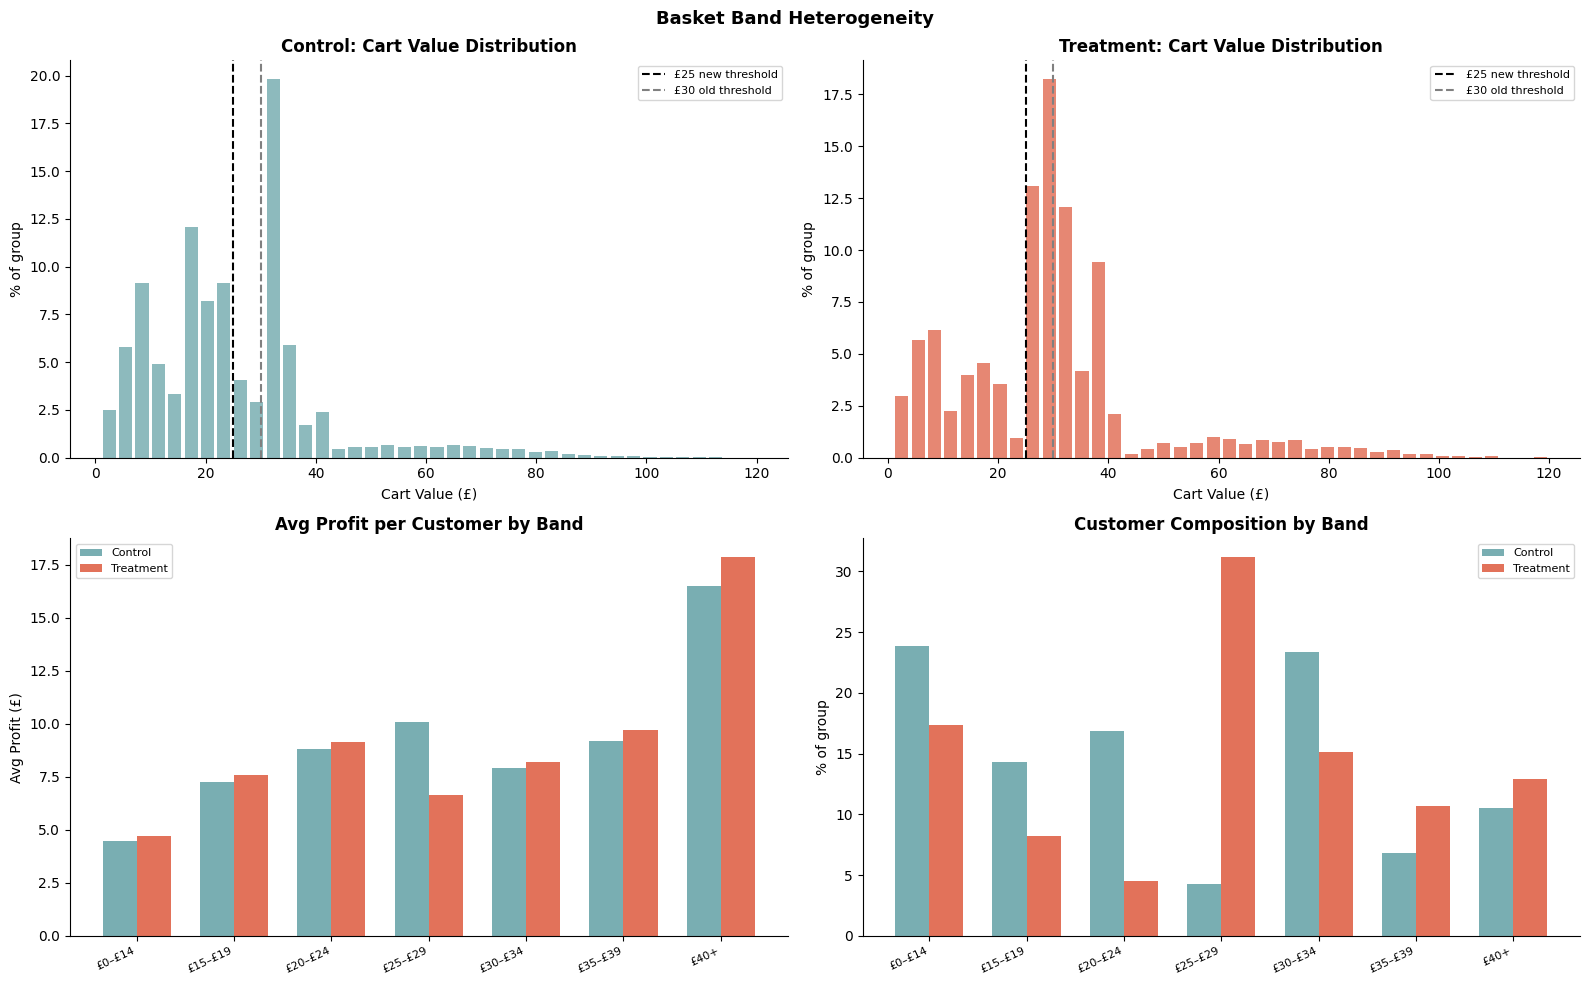

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Basket Band Heterogeneity",
             fontsize=13, fontweight="bold")

bins = np.histogram_bin_edges(df["cart_value_pre_shipping"], bins=40)
centers = (bins[:-1] + bins[1:]) / 2
w = (bins[1] - bins[0]) * 0.8

# Plot 1 — Control histogram
ax = axes[0, 0]
counts, _ = np.histogram(ctrl["cart_value_pre_shipping"], bins=bins)
ax.bar(centers, counts / counts.sum() * 100, width=w, color=CTRL, alpha=0.85)
ax.axvline(25, color="black", linestyle="--", linewidth=1.5, label="£25 new threshold")
ax.axvline(30, color="grey",   linestyle="--", linewidth=1.5, label="£30 old threshold")
ax.set_title("Control: Cart Value Distribution", fontweight="bold")
ax.set_xlabel("Cart Value (£)"); ax.set_ylabel("% of group")
ax.legend(fontsize=8)

# Plot 2 — Treatment histogram
ax2 = axes[0, 1]
counts, _ = np.histogram(trt["cart_value_pre_shipping"], bins=bins)
ax2.bar(centers, counts / counts.sum() * 100, width=w, color=TRT, alpha=0.85)
ax2.axvline(25, color="black", linestyle="--", linewidth=1.5, label="£25 new threshold")
ax2.axvline(30, color="grey",   linestyle="--", linewidth=1.5, label="£30 old threshold")
ax2.set_title("Treatment: Cart Value Distribution", fontweight="bold")
ax2.set_xlabel("Cart Value (£)"); ax2.set_ylabel("% of group")
ax2.legend(fontsize=8)

# Plot 3 — Avg profit by band
ax3 = axes[1, 0]
profit_band = df.groupby(["cart_band", "treatment"])["profit_per_customer"].mean().unstack()
profit_band.columns = ["Control", "Treatment"]
x = np.arange(len(profit_band))
bw = 0.35
ax3.bar(x - bw/2, profit_band["Control"],   width=bw, color=CTRL, label="Control")
ax3.bar(x + bw/2, profit_band["Treatment"], width=bw, color=TRT,  label="Treatment")
ax3.set_xticks(x)
ax3.set_xticklabels(profit_band.index, rotation=25, ha="right", fontsize=8)
ax3.set_title("Avg Profit per Customer by Band", fontweight="bold")
ax3.set_ylabel("Avg Profit (£)"); ax3.legend(fontsize=8)

# Plot 4 — Composition shift
ax4 = axes[1, 1]
band_pct = df.groupby(["cart_band", "treatment"]).size().unstack()
band_pct_norm = band_pct.div(band_pct.sum()).mul(100)
band_pct_norm.columns = ["Control", "Treatment"]
ax4.bar(x - bw/2, band_pct_norm["Control"],   width=bw, color=CTRL, label="Control")
ax4.bar(x + bw/2, band_pct_norm["Treatment"], width=bw, color=TRT,  label="Treatment")
ax4.set_xticks(x)
ax4.set_xticklabels(band_pct_norm.index, rotation=25, ha="right", fontsize=8)
ax4.set_title("Customer Composition by Band", fontweight="bold")
ax4.set_ylabel("% of group"); ax4.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 4. Channel Analysis

  Channel  Control Mean  Treatment Mean  Lift  p-value Significant
   TikTok          8.30            8.85  0.55   0.0013         Yes
   Google          8.04            8.34  0.30   0.0857          No
Instagram          8.20            8.38  0.18   0.2162          No
    Other          8.27            8.39  0.11   0.6692          No
 Facebook          8.39            8.49  0.10   0.6620          No


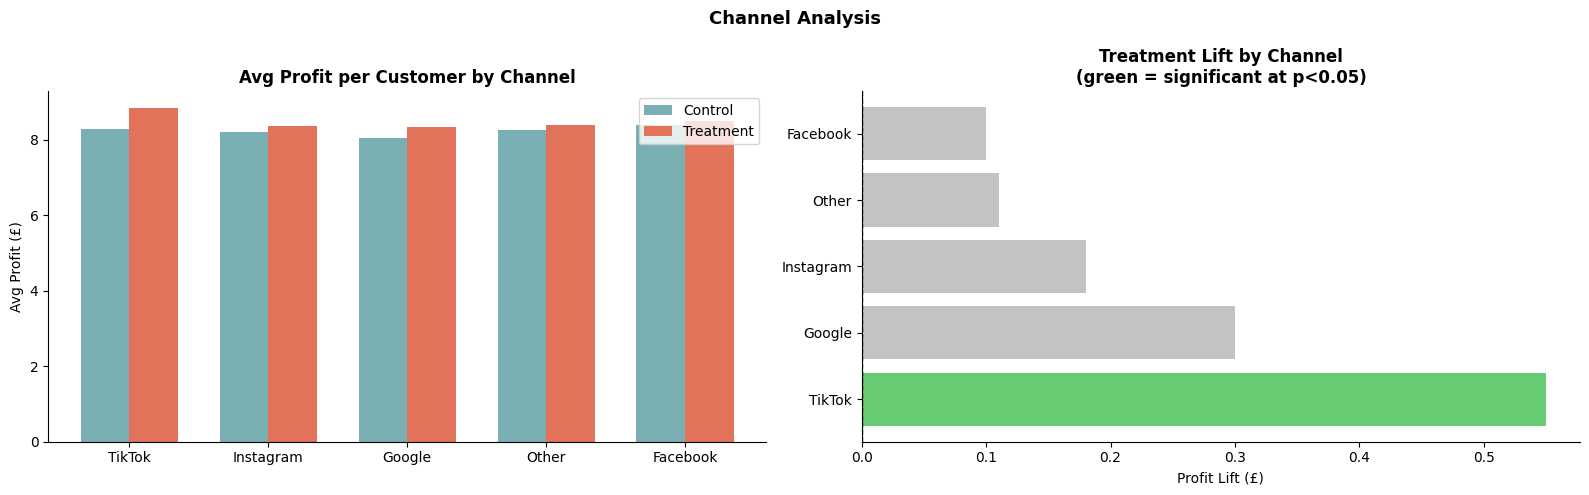

In [43]:
# Treatment lift by channel
channels = ["TikTok", "Instagram", "Google", "Other", "Facebook"]
results = []
for ch in channels:
    c = df[(df["channel"] == ch) & (df["treatment"] == 0)]["profit_per_customer"]
    t = df[(df["channel"] == ch) & (df["treatment"] == 1)]["profit_per_customer"]
    t_stat, p_val = stats.ttest_ind(c, t)
    results.append({
        "Channel":        ch,
        "Control Mean":   round(c.mean(), 2),
        "Treatment Mean": round(t.mean(), 2),
        "Lift":           round(t.mean() - c.mean(), 2),
        "p-value":        round(p_val, 4),
        "Significant":    "Yes" if p_val < 0.05 else "No"
    })

summary = pd.DataFrame(results).sort_values("Lift", ascending=False)
print(summary.to_string(index=False))

# Charts
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Channel Analysis",
             fontsize=13, fontweight="bold")

# Plot 1 — Avg profit by channel, control vs treatment
ax = axes[0]
x = np.arange(len(channels))
w = 0.35
ctrl_means = [df[(df["channel"]==ch)&(df["treatment"]==0)]["profit_per_customer"].mean() for ch in channels]
trt_means  = [df[(df["channel"]==ch)&(df["treatment"]==1)]["profit_per_customer"].mean() for ch in channels]
ax.bar(x - w/2, ctrl_means, width=w, color=CTRL, label="Control")
ax.bar(x + w/2, trt_means,  width=w, color=TRT,  label="Treatment")
ax.set_xticks(x)
ax.set_xticklabels(channels)
ax.set_title("Avg Profit per Customer by Channel", fontweight="bold")
ax.set_ylabel("Avg Profit (£)")
ax.legend()

# Plot 2 — Lift by channel with significance
ax2 = axes[1]
colors = ["#67CB73" if p < 0.05 else "#c3c3c3" for p in summary["p-value"]]
ax2.barh(summary["Channel"], summary["Lift"], color=colors)
ax2.axvline(0, color="black", linewidth=1, linestyle="--")
ax2.set_title("Treatment Lift by Channel\n(green = significant at p<0.05)",
              fontweight="bold")
ax2.set_xlabel("Profit Lift (£)")

plt.tight_layout()
plt.show()

### 5. Device Analysis

                   profit_per_customer  order_value
device  treatment                                  
desktop 0                         8.35        25.83
        1                         8.34        28.63
mobile  0                         8.17        25.18
        1                         8.58        29.81

Mobile
  Control: £8.17  |  Treatment: £8.58  |  Lift: £+0.40
  t=-4.021, p=0.0001  Significant

Desktop
  Control: £8.35  |  Treatment: £8.34  |  Lift: £-0.01
  t=0.038, p=0.9695  Not significant


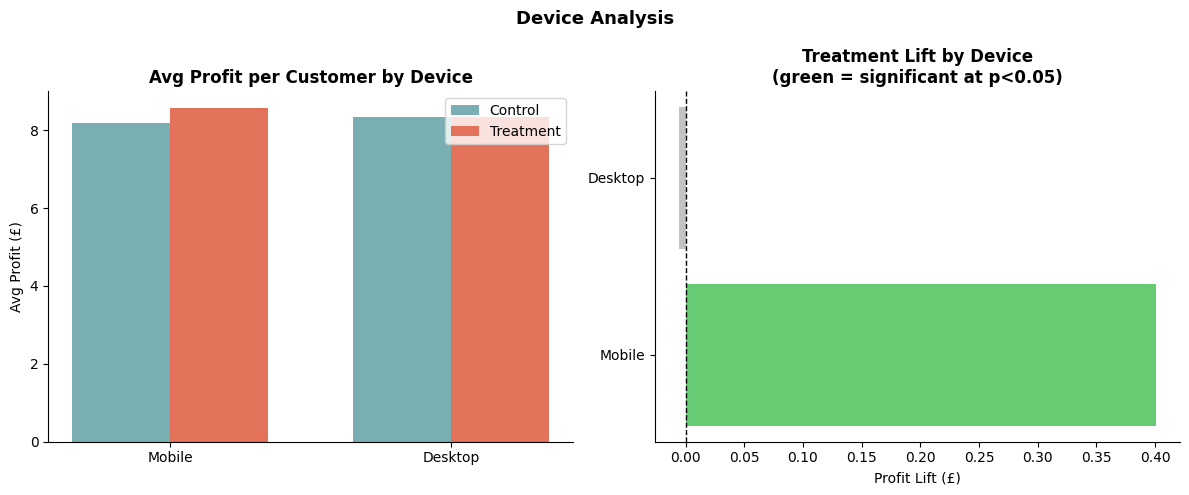

In [48]:
# Means by device × treatment
device_summary = df.groupby(["device", "treatment"])[["profit_per_customer", "order_value"]].mean().round(2)
print(device_summary)

# T-test per device
for dev in ["mobile", "desktop"]:
    c = df[(df["device"]==dev) & (df["treatment"]==0)]["profit_per_customer"]
    t = df[(df["device"]==dev) & (df["treatment"]==1)]["profit_per_customer"]
    t_stat, p_val = stats.ttest_ind(c, t)
    print(f"\n{dev.title()}")
    print(f"  Control: £{c.mean():.2f}  |  Treatment: £{t.mean():.2f}  |  Lift: £{t.mean()-c.mean():+.2f}")
    print(f"  t={t_stat:.3f}, p={p_val:.4f}  {'Significant' if p_val < 0.05 else 'Not significant'}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Device Analysis", fontsize=13, fontweight="bold")

devices = ["Mobile", "Desktop"]

# Plot 1 — Avg profit by device × treatment
ax = axes[0]
x = np.arange(len(devices))
w = 0.35
ctrl_means = [df[(df["device"]==d.lower())&(df["treatment"]==0)]["profit_per_customer"].mean() for d in devices]
trt_means  = [df[(df["device"]==d.lower())&(df["treatment"]==1)]["profit_per_customer"].mean() for d in devices]
ax.bar(x - w/2, ctrl_means, width=w, color=CTRL, label="Control")
ax.bar(x + w/2, trt_means,  width=w, color=TRT,  label="Treatment")
ax.set_xticks(x)
ax.set_xticklabels(devices)
ax.set_title("Avg Profit per Customer by Device", fontweight="bold")
ax.set_ylabel("Avg Profit (£)")
ax.legend()

# Plot 2 — Lift by device with significance
ax2 = axes[1]
lifts, colors_bar, labels = [], [], []
for d in devices:
    c = df[(df["device"]==d.lower())&(df["treatment"]==0)]["profit_per_customer"]
    t = df[(df["device"]==d.lower())&(df["treatment"]==1)]["profit_per_customer"]
    _, p = stats.ttest_ind(c, t)
    lifts.append(t.mean() - c.mean())
    colors_bar.append("#67CB73" if p < 0.05 else "#c3c3c3")


ax2.barh(devices, lifts, color=colors_bar)
ax2.axvline(0, color="black", linewidth=1, linestyle="--")
ax2.set_title("Treatment Lift by Device\n(green = significant at p<0.05)", fontweight="bold")
ax2.set_xlabel("Profit Lift (£)")

plt.tight_layout()
plt.show()

### 6. New/Returing Customer Analysis


New
  Control: £8.19  |  Treatment: £8.42  |  Lift: £+0.23
  t=-2.217, p=0.0266  Significant

Returning
  Control: £8.29  |  Treatment: £8.64  |  Lift: £+0.35
  t=-2.599, p=0.0094  Significant


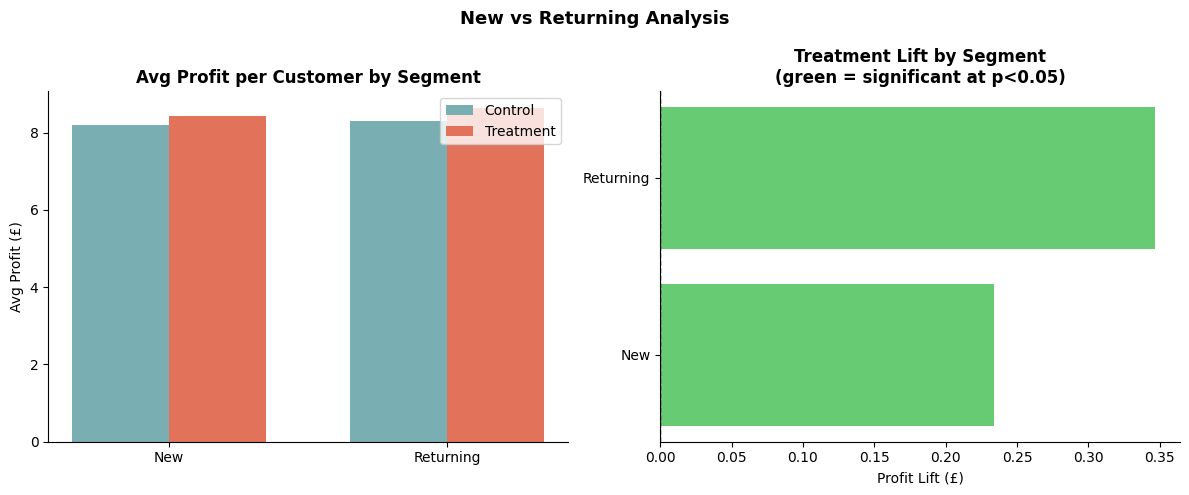

In [51]:
segments = ["new", "returning"]

# T-test per segment
for seg in segments:
    c = df[(df["new_returning"]==seg) & (df["treatment"]==0)]["profit_per_customer"]
    t = df[(df["new_returning"]==seg) & (df["treatment"]==1)]["profit_per_customer"]
    t_stat, p_val = stats.ttest_ind(c, t)
    print(f"\n{seg.title()}")
    print(f"  Control: £{c.mean():.2f}  |  Treatment: £{t.mean():.2f}  |  Lift: £{t.mean()-c.mean():+.2f}")
    print(f"  t={t_stat:.3f}, p={p_val:.4f}  {'Significant' if p_val < 0.05 else 'Not significant'}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("New vs Returning Analysis", fontsize=13, fontweight="bold")

x = np.arange(len(segments))
w = 0.35

# Plot 1 — Avg profit by segment × treatment
ax = axes[0]
ctrl_means = [df[(df["new_returning"]==s)&(df["treatment"]==0)]["profit_per_customer"].mean() for s in segments]
trt_means  = [df[(df["new_returning"]==s)&(df["treatment"]==1)]["profit_per_customer"].mean() for s in segments]
ax.bar(x - w/2, ctrl_means, width=w, color=CTRL, label="Control")
ax.bar(x + w/2, trt_means,  width=w, color=TRT,  label="Treatment")
ax.set_xticks(x)
ax.set_xticklabels([s.title() for s in segments])
ax.set_title("Avg Profit per Customer by Segment", fontweight="bold")
ax.set_ylabel("Avg Profit (£)")
ax.legend()

# Plot 2 — Lift by segment with significance
ax2 = axes[1]
lifts, colors_bar = [], []
for seg in segments:
    c = df[(df["new_returning"]==seg)&(df["treatment"]==0)]["profit_per_customer"]
    t = df[(df["new_returning"]==seg)&(df["treatment"]==1)]["profit_per_customer"]
    _, p = stats.ttest_ind(c, t)
    lifts.append(t.mean() - c.mean())
    colors_bar.append("#67CB73" if p < 0.05 else "#c3c3c3")

ax2.barh([s.title() for s in segments], lifts, color=colors_bar)
ax2.axvline(0, color="black", linewidth=1, linestyle="--")
ax2.set_title("Treatment Lift by Segment\n(green = significant at p<0.05)", fontweight="bold")
ax2.set_xlabel("Profit Lift (£)")

plt.tight_layout()
plt.show()